In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns  
import os 
import glob 
from pathlib import Path 
import monai 
from monai.losses import DiceLoss 
from monai.networks.nets import SegResNet 
from monai.inferers import sliding_window_inference  
from monai.data import CacheDataset, DataLoader 
from monai.metrics import DiceMetric 
from monai.handlers import decollate_batch 
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    Orientationd,
    Spacingd,
    EnsureTyped,
    RandFlipd,
    Resized,
    RandCropByPosNegLabeld,
)
import torch 
import psutil # see ram 
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm 
from sklearn.model_selection import train_test_split 

In [2]:
mem_info = psutil.virtual_memory()
print(f"Total RAM: {mem_info.total / (1024**3):.2f} GB")
print(f"Used RAM: {mem_info.used / (1024**3):.2f} GB")
print(f"Available RAM: {mem_info.available / (1024**3):.2f} GB")
print(f"RAM Usage Percentage: {mem_info.percent}%")

Total RAM: 24.00 GB
Used RAM: 11.36 GB
Available RAM: 9.02 GB
RAM Usage Percentage: 62.4%


<h3>

0: Background

1: Hippocampus Anterior (Head)

2: Hippocampus Posterior (Body/Tail) 
</h3>

### Augmentations Order 
<code>

- LoadImagd 

- EnsureChannelFirstd 

- ScaleIntensityd 

- Orientationd 

- Spacingd 

- RandCropByPosNegLabeld 

- Resized 

- RandFlipd 

- EnsureTyped 

</code>


In [4]:
train_transforms = Compose([
    LoadImaged(keys=['image', 'label']),
    EnsureChannelFirstd(keys=['image', 'label']),
    ScaleIntensityd(keys=['image']),
    Orientationd(keys=['image', 'label'], axcodes='RAS'),
    Spacingd(keys=['image', 'label'], pixdim=(1.0, 1.0, 1.0), mode=('bilinear', 'nearest')),
    RandCropByPosNegLabeld(
        keys=['image', 'label'], 
        spatial_size=(16, 16, 16), 
        pos=2, 
        neg=1, 
        num_samples=1,  # Back to 1 to avoid batch size issues
        label_key='label',
        image_key='image',  
    ),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=[0, 1, 2]),
    Resized(keys=["image", "label"], spatial_size=(16, 16, 16)),
    EnsureTyped(keys=['image', 'label'], data_type = "tensor"),
])

test_transforms = Compose([
    LoadImaged(keys=['image', 'label']),
    EnsureChannelFirstd(keys=['image', 'label']),
    ScaleIntensityd(keys=['image']),
    Orientationd(keys=['image', 'label'], axcodes='RAS'),
    Spacingd(keys=['image', 'label'], pixdim=(1.0, 1.0, 1.0), mode=('bilinear', 'nearest')),
    Resized(keys=["image", "label"], spatial_size=(32, 48, 32)), # Divisible by 8 
    EnsureTyped(keys=['image', 'label'], data_type = "tensor"),
])

/Users/ryanchen/.virtualenvs/.venv/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [5]:
X = sorted(glob.glob("Task04_Hippocampus/imagesTr/*.nii.gz"))
y = sorted(glob.glob("Task04_Hippocampus/labelsTr/*.nii.gz"))

train_imgs, test_imgs, train_labels, test_labels = train_test_split(X, y, test_size=0.2, random_state=42)

train_ds = [{"image": img, "label": label} for img, label in zip(train_imgs, train_labels)]
test_ds = [{"image": img, "label": label} for img, label in zip(test_imgs, test_labels)]
print(len(train_ds))
print(len(test_ds))

208
52


In [6]:
train_ds = CacheDataset(data=train_ds, transform=train_transforms, cache_rate=1.0, num_workers=0)
test_ds = CacheDataset(data=test_ds, transform=test_transforms, cache_rate=1.0, num_workers=0)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=16, num_workers=0, pin_memory=True)

Loading dataset: 100%|██████████| 52/52 [00:00<00:00, 176.30it/s]


torch.Size([1, 32, 48, 32])


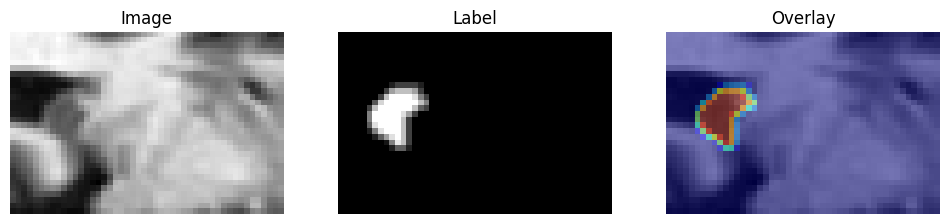

In [ ]:
### View sample from test set 
def view_sample(i, depth = 20):
    fig, axes = plt.subplots(1,3, figsize = (12,12))
    axes[0].imshow(test_ds[i]['image'][0, :, :, depth], cmap = "gray")
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(test_ds[i]['label'][0, :, :, depth], cmap = "gray")
    axes[1].set_title("Label")
    axes[1].axis("off")

    # Overlay 
    axes[2].imshow(test_ds[i]['image'][0, :, :, depth], cmap = "gray")
    axes[2].imshow(test_ds[i]['label'][0, :, :, depth], alpha = 0.5, cmap = "jet")
    axes[2].set_title("Overlay")
    axes[2].axis("off")
    
    print(test_ds[i]['image'].shape)
    plt.show()

view_sample(20)

In [64]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
EPOCHS = 200
model = SegResNet(
    spatial_dims=3, 
    in_channels=1, 
    out_channels=3, 
    init_filters=64, 
    dropout_prob=0.3, 
    norm = "batch"
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), 2E-4, weight_decay = 1E-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min = 1E-6)
loss_fn = DiceLoss(to_onehot_y=True, sigmoid = True, squared_pred=True)
dice_metric = DiceMetric(include_background=False, reduction="mean")

In [65]:
import gc 

### Train loop with validation and early stopping
losses = [] 
val_losses = []
val_dice_scores = []
patience = 20
best_val_loss = float('inf')

for epoch in tqdm(range(EPOCHS)):
    model.train()
    avg_train_loss = 0
    avg_test_loss = 0 
    print(f"Epoch {epoch} \n", "-" * 50)
    for data in train_loader:
        img, label = data["image"].to(device), data["label"].to(device)
        pred = model(img)
        loss = loss_fn(pred, label)
        optimizer.zero_grad(set_to_none = True)
        loss.backward()
        optimizer.step()
        avg_train_loss += loss.item()
    losses.append(avg_train_loss / len(train_loader))
    print(f"Avg Train Loss: {avg_train_loss / len(train_loader)}")

    model.eval()
    dice_metric.reset()  # Reset dice metric for new evaluation
    with torch.inference_mode():
        for data in test_loader:
            img, label = data["image"].to(device), data["label"].to(device)
            pred = model(img)
            test_loss = loss_fn(pred, label)
            avg_test_loss += test_loss.item()
            
            # Calculate dice score
            pred_sigmoid = torch.sigmoid(pred)
            pred_onehot = (pred_sigmoid > 0.5).float()
            dice_metric(y_pred=pred_onehot, y=label)
            
            del img, label, pred, test_loss, pred_sigmoid, pred_onehot
    val_losses.append(avg_test_loss / len(test_loader))
    
    # Get current dice score
    current_dice = dice_metric.aggregate().item()
    val_dice_scores.append(current_dice)
    
    print(f"Val Loss: {avg_test_loss / len(test_loader)}")
    print(f"Val Dice Score: {current_dice:.4f}")
    
    # Collect garbage
    gc.collect()
    torch.mps.empty_cache()

    # Early stopping - track val loss 
    if avg_test_loss / len(test_loader) < best_val_loss:
        best_val_loss = avg_test_loss / len(test_loader)
        patience = 20
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved model")
        print(f"Best validation loss: {best_val_loss}")
        print(f"Current Dice Score: {current_dice:.4f}")
    else:
        patience -= 1
        if patience == 0:
            print("Early stopping")
            break

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 0 
 --------------------------------------------------


/Users/ryanchen/.virtualenvs/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Avg Train Loss: 0.5703689272587116
Val Loss: 0.6952634453773499
Val Dice Score: 0.0607
Saved model
Best validation loss: 0.6952634453773499
Current Dice Score: 0.0607
Epoch 1 
 --------------------------------------------------
Avg Train Loss: 0.5334173670181861
Val Loss: 0.6943925321102142
Val Dice Score: 0.0601
Saved model
Best validation loss: 0.6943925321102142
Current Dice Score: 0.0601
Epoch 2 
 --------------------------------------------------
Avg Train Loss: 0.5130934967444494
Val Loss: 0.6289410293102264
Val Dice Score: 0.1354
Saved model
Best validation loss: 0.6289410293102264
Current Dice Score: 0.1354
Epoch 3 
 --------------------------------------------------
Avg Train Loss: 0.5066765157076029
Val Loss: 0.6068319827318192
Val Dice Score: 0.1609
Saved model
Best validation loss: 0.6068319827318192
Current Dice Score: 0.1609
Epoch 4 
 --------------------------------------------------
Avg Train Loss: 0.4770565330982208
Val Loss: 0.5832047462463379
Val Dice Score: 0.2690
S

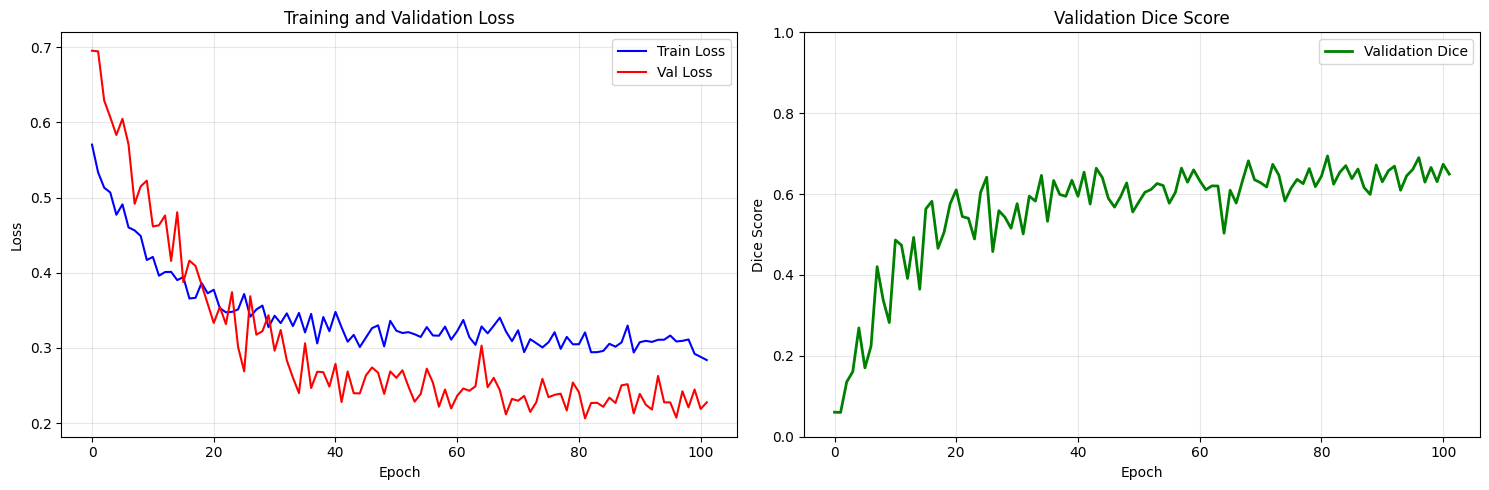

Best Validation Dice Score: 0.6944
Final Training Loss: 0.2838
Final Validation Loss: 0.2276


In [66]:
# Enhanced visualization with metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1.plot(losses, label="Train Loss", color='blue')
ax1.plot(val_losses, label="Val Loss", color='red')
ax1.set_title("Training and Validation Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Dice score curve
ax2.plot(val_dice_scores, label="Validation Dice", color='green', linewidth=2)
ax2.set_title("Validation Dice Score")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Dice Score")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"Best Validation Dice Score: {max(val_dice_scores):.4f}")
print(f"Final Training Loss: {losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

### Prediction time 

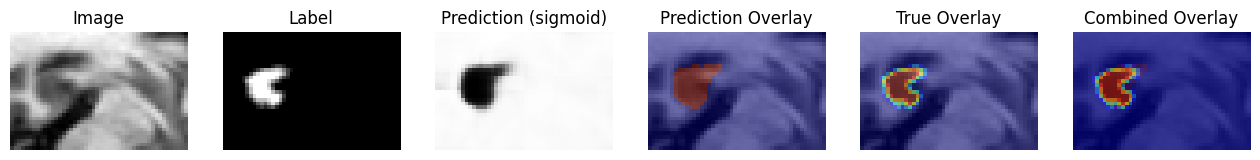

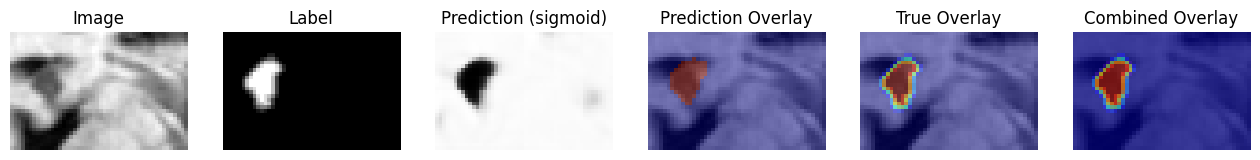

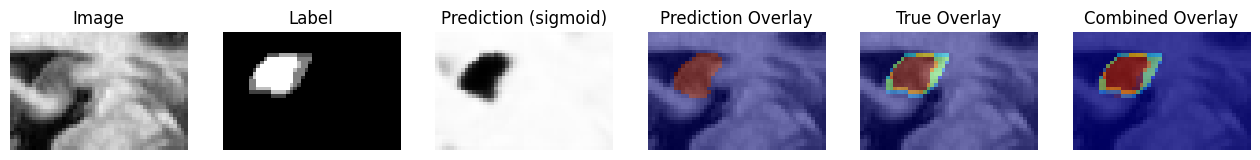

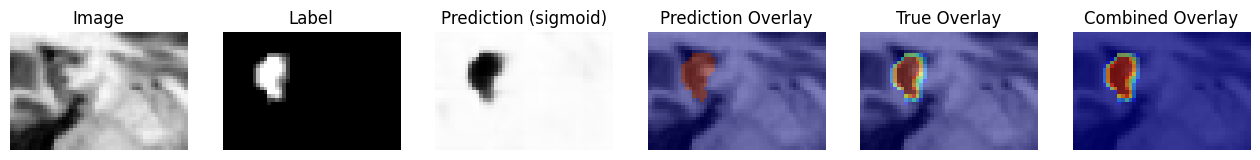

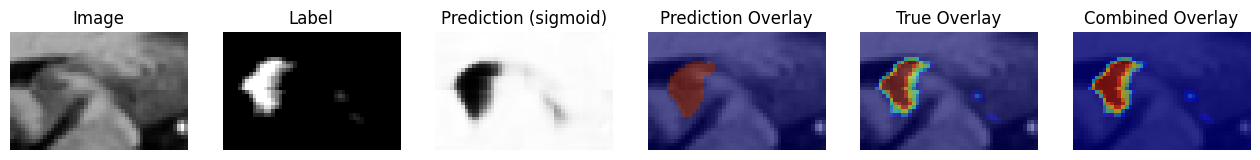

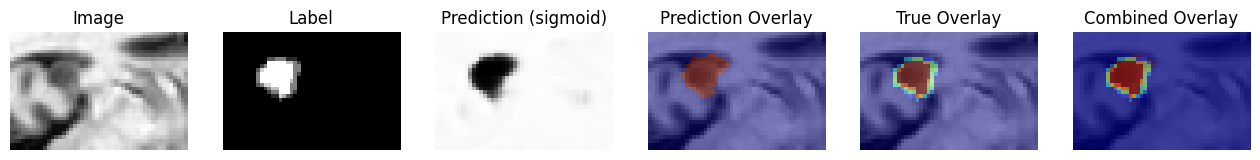

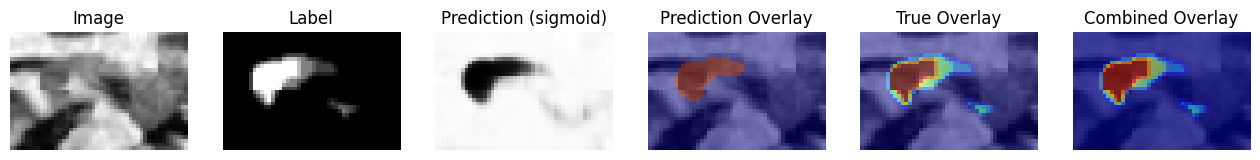

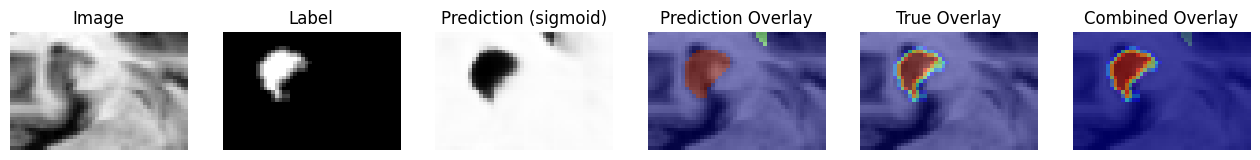

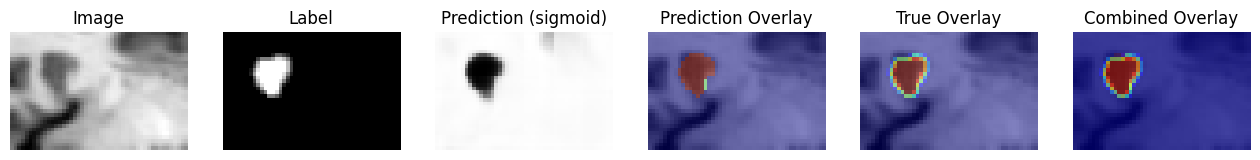

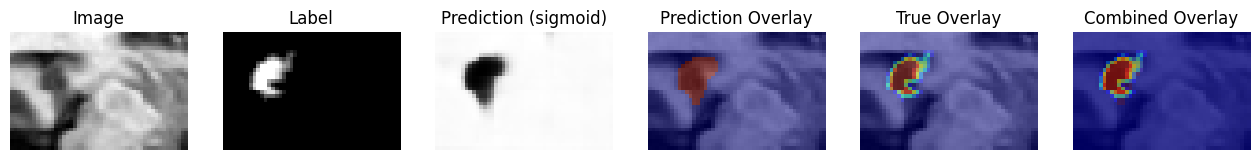

In [ ]:
### View sample from test set 
@torch.inference_mode()
def view_test_sample(i, depth = 18, channel = 0):
    # Original Image
    fig, axes = plt.subplots(1,6, figsize = (16,18))
    axes[0].imshow(test_ds[i]['image'][channel, :, :, depth], cmap = "gray")
    axes[0].set_title("Image")
    axes[0].axis("off")

    # True label 
    axes[1].imshow(test_ds[i]['label'][channel, :, :, depth], cmap = "gray")
    axes[1].set_title("Label")
    axes[1].axis("off")

    # Model prediction
    model.eval()
    model.to(device)
    with torch.no_grad():
        pred = sliding_window_inference(test_ds[i]['image'].unsqueeze(0).to(device), (16, 16, 16), 1, model, overlap=0.25)
        pred_sigmoid = torch.sigmoid(pred)
        pred_class = torch.argmax(pred_sigmoid, dim=1, keepdim=True)
        
        axes[2].imshow(pred_sigmoid[0, channel, :, :, depth].cpu(), cmap = "gray")
        axes[2].set_title("Prediction (sigmoid)")
        axes[2].axis("off")
    
    # Model Overlay - fix shape issue
    axes[3].imshow(test_ds[i]['image'][channel, :, :, depth], cmap = "gray")
    axes[3].imshow(pred_class[0, 0, :, :, depth].cpu(), alpha = 0.5, cmap = "jet")
    axes[3].set_title("Prediction Overlay")
    axes[3].axis("off")

    # True Overlay
    axes[4].imshow(test_ds[i]['image'][channel, :, :, depth], cmap = "gray")
    axes[4].imshow(test_ds[i]['label'][channel, :, :, depth], alpha = 0.5, cmap = "jet")
    axes[4].set_title("True Overlay")
    axes[4].axis("off")

    # Combined Overlay
    axes[5].imshow(test_ds[i]['image'][channel, :, :, depth], cmap = "gray")
    axes[5].imshow(pred_class[0, 0, :, :, depth].cpu(), alpha = 0.5, cmap = "jet")
    axes[5].imshow(test_ds[i]['label'][channel, :, :, depth], alpha = 0.5, cmap = "jet")
    axes[5].set_title("Combined Overlay")
    axes[5].axis("off")
    
    plt.show()

for i in range(10):
    view_test_sample(i+30)

### Convert to onnx

In [8]:
import onnx
import onnxruntime as ort
from monai.transforms import (
    LoadImage, EnsureChannelFirst, ScaleIntensity, 
    Orientation, Spacing, Resize, EnsureType 
)

In [ ]:
model = SegResNet(
    spatial_dims=3, 
    in_channels=1, 
    out_channels=3, 
    init_filters=64, 
    norm = "batch"
)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

model_cpu = model.to('cpu')

# Just do entire image into the model at once 
dummy_input = torch.randn(1, 1, 32, 48, 32)

# Export the model to ONNX
torch.onnx.export(
    model_cpu,
    dummy_input,
    "hippocampus_segmentation.onnx",
    export_params=True,
    opset_version=11,  # Use opset version compatible with most inference engines
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size', 2: 'depth', 3: 'height', 4: 'width'},
        'output': {0: 'batch_size', 2: 'depth', 3: 'height', 4: 'width'}
    }
)

print("Model exported to hippocampus_segmentation.onnx")

/var/folders/48/zbjkv1yj21z39_39xks8g9580000gn/T/ipykernel_89976/3769914404.py:25: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0315 15:29:01.407000 89976 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0315 15:29:01.742000 89976 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scal

[torch.onnx] Obtain model graph for `SegResNet([...]` with `torch.export.export(..., strict=False)`...


W0315 15:29:02.011000 89976 torch/fx/experimental/symbolic_shapes.py:6833] _maybe_guard_rel() was called on non-relation expression ((((s0 - 1)//4)) + 1 > 0) | ((((s53 - 1)//4)) + 1 > 0) | ((((s92 - 1)//4)) + 1 > 0)
W0315 15:29:02.161000 89976 torch/fx/experimental/symbolic_shapes.py:6833] _maybe_guard_rel() was called on non-relation expression ((((s0 - 1)//8)) + 1 > 0) | ((((s53 - 1)//8)) + 1 > 0) | ((((s92 - 1)//8)) + 1 > 0)


[torch.onnx] Obtain model graph for `SegResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/ryanchen/.virtualenvs/.venv/lib/python3.13/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/Users/ryanchen/.virtualenvs/.venv/lib/python3.13/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/Users/ryanchen/.virtualenvs/.venv/lib/python3.13/site-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, targe

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 43 of general pattern rewrite rules.
Model exported to hippocampus_segmentation.onnx
ONNX model is valid


### Evaluate
- 52 Validation Images

In [14]:
onnx_model = onnx.load("hippocampus_segmentation.onnx")
onnx.checker.check_model(onnx_model)
print("ONNX model is valid")

model = SegResNet(
    spatial_dims=3, 
    in_channels=1, 
    out_channels=3, 
    init_filters=64, 
    norm = "batch"
)

model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
model.eval()
print("Model loaded successfully")

dice_metric = DiceMetric(include_background=False, reduction="mean")

ONNX model is valid
Model loaded successfully


Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_049.nii.gz


/Users/ryanchen/.virtualenvs/.venv/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.array Orientation.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
/Users/ryanchen/.virtualenvs/.venv/lib/python3.13/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/p

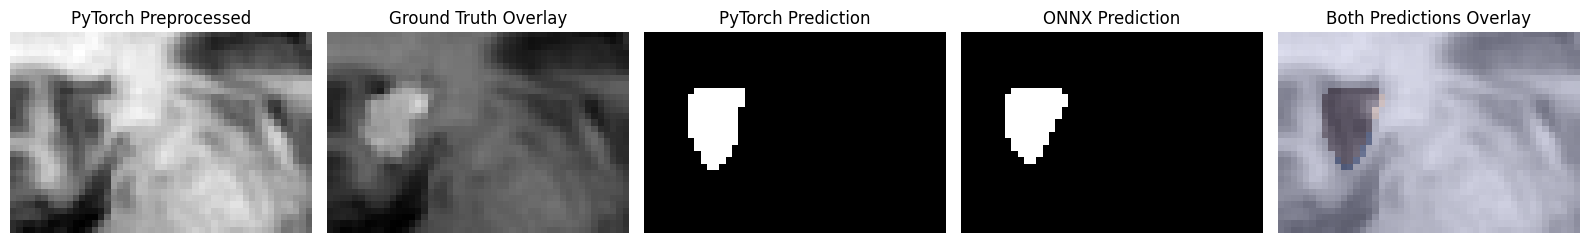

PyTorch Dice Score: 0.7079
ONNX Dice Score: 0.7426
Difference: 0.0348
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_288.nii.gz


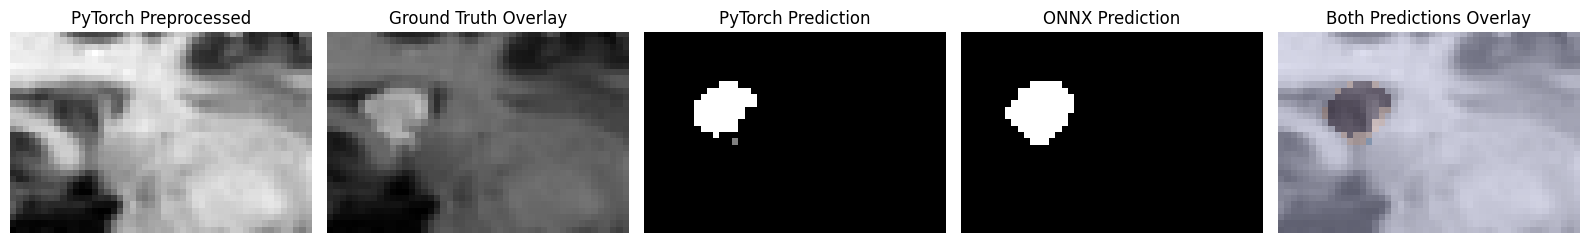

PyTorch Dice Score: 0.6887
ONNX Dice Score: 0.7124
Difference: 0.0237
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_340.nii.gz


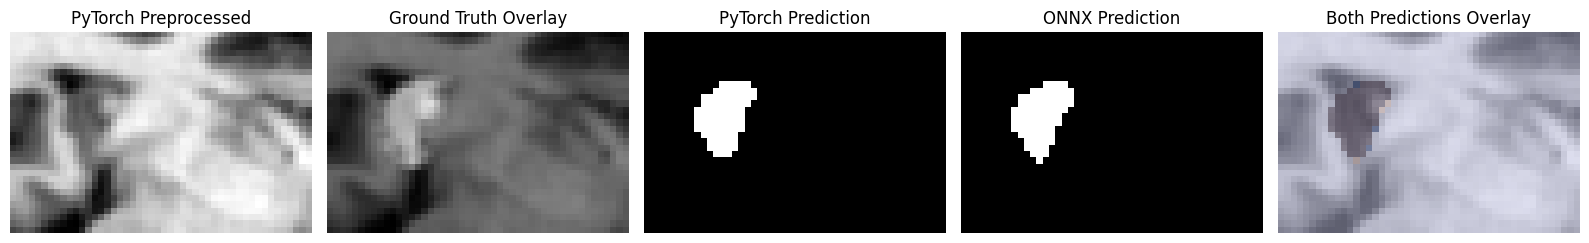

PyTorch Dice Score: 0.6633
ONNX Dice Score: 0.6866
Difference: 0.0233
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_294.nii.gz


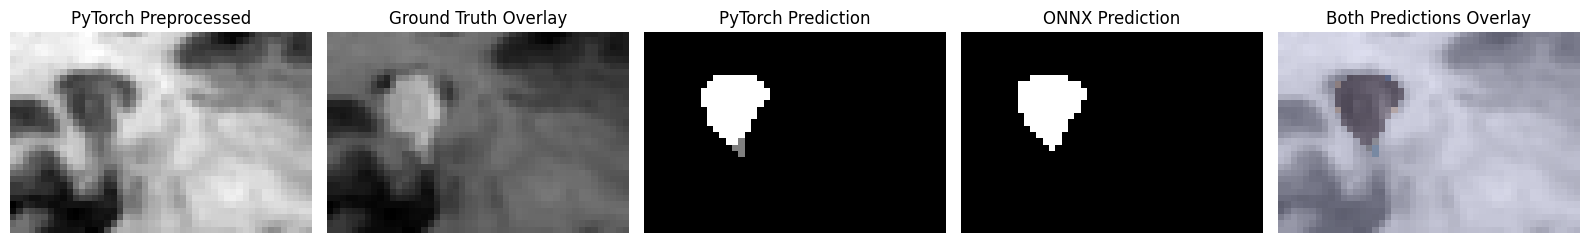

PyTorch Dice Score: 0.6383
ONNX Dice Score: 0.6850
Difference: 0.0467
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_327.nii.gz


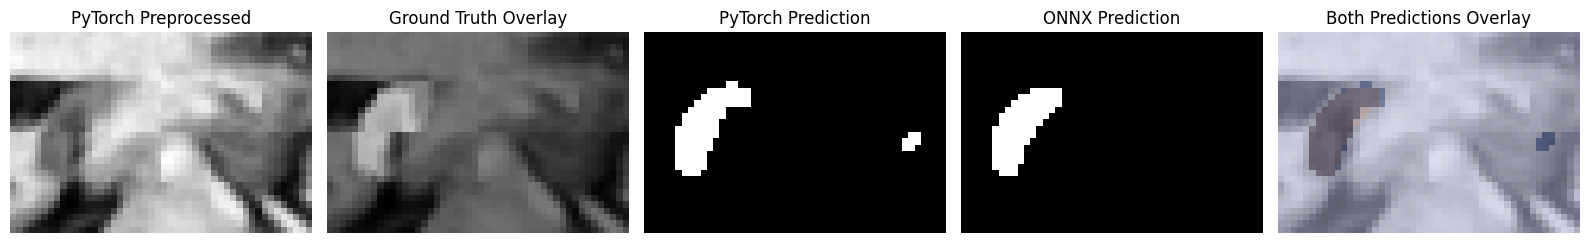

PyTorch Dice Score: 0.7393
ONNX Dice Score: 0.7537
Difference: 0.0144
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_393.nii.gz


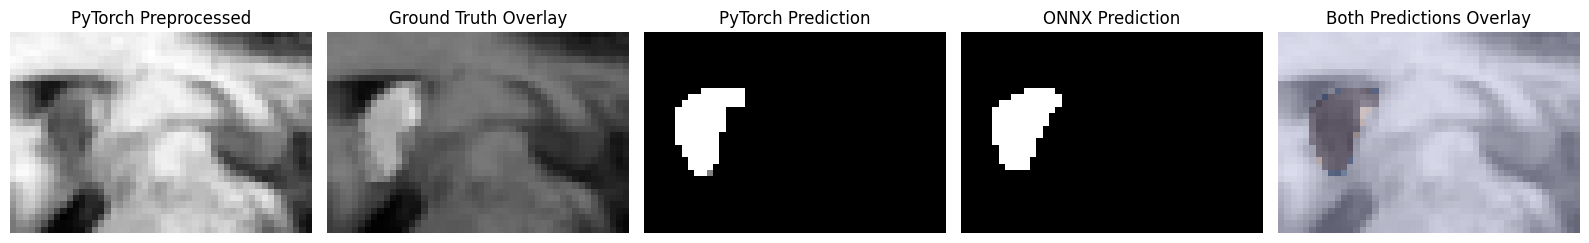

PyTorch Dice Score: 0.7061
ONNX Dice Score: 0.7448
Difference: 0.0387
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_274.nii.gz


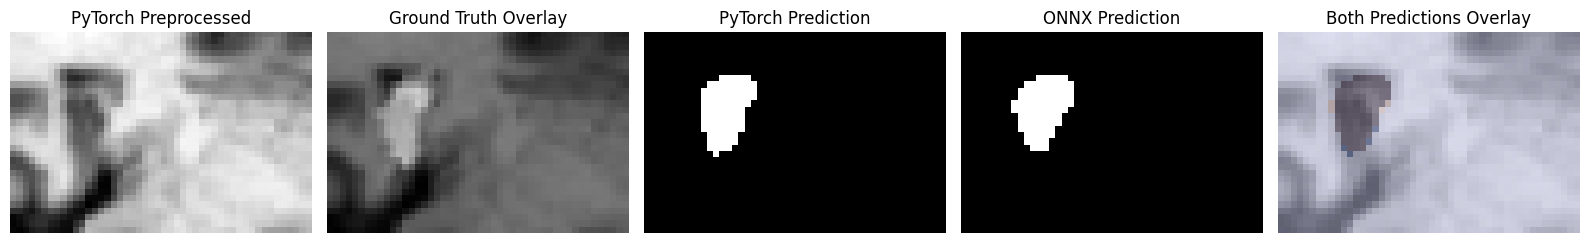

PyTorch Dice Score: 0.6254
ONNX Dice Score: 0.6575
Difference: 0.0320
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_226.nii.gz


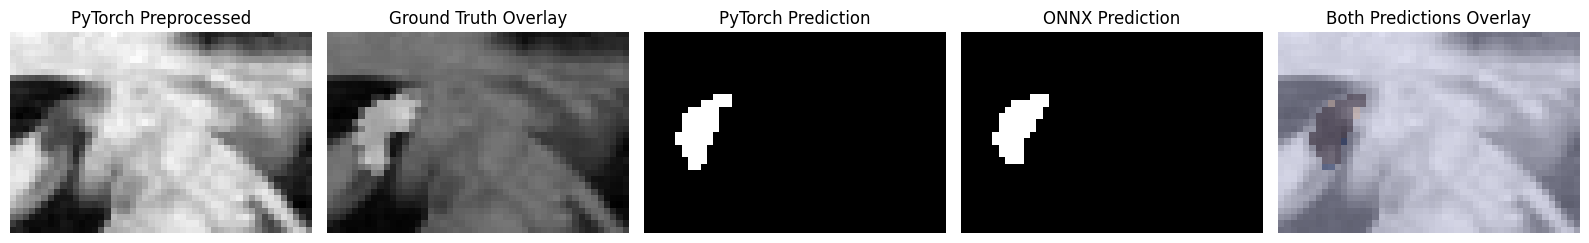

PyTorch Dice Score: 0.6855
ONNX Dice Score: 0.6526
Difference: 0.0329
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_017.nii.gz


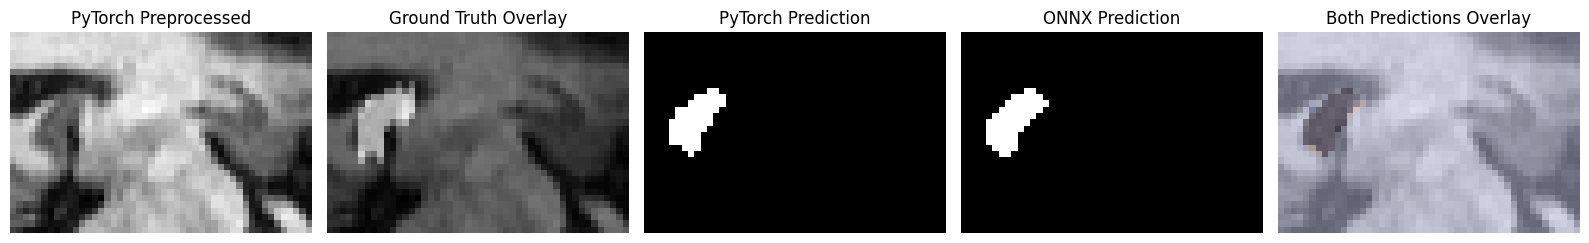

PyTorch Dice Score: 0.7719
ONNX Dice Score: 0.8001
Difference: 0.0282
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_280.nii.gz


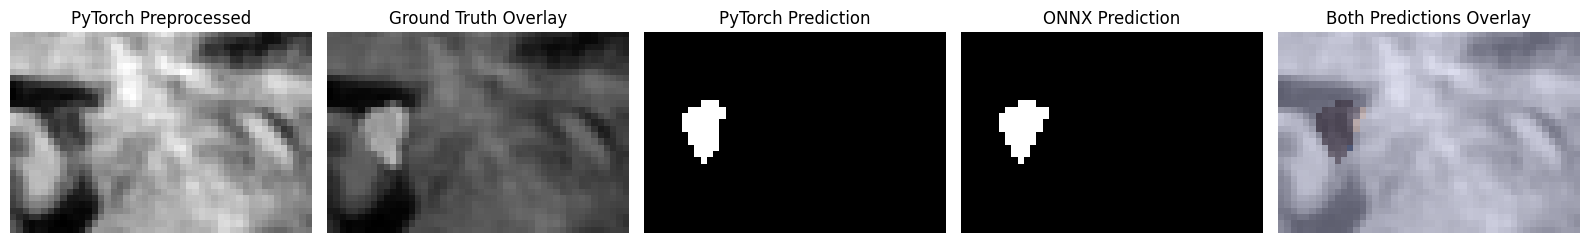

PyTorch Dice Score: 0.6442
ONNX Dice Score: 0.6594
Difference: 0.0152
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_041.nii.gz


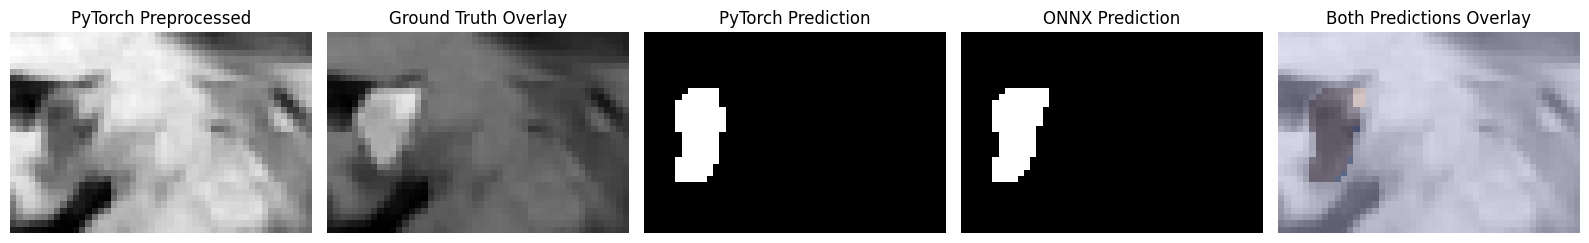

PyTorch Dice Score: 0.6872
ONNX Dice Score: 0.7051
Difference: 0.0180
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_329.nii.gz


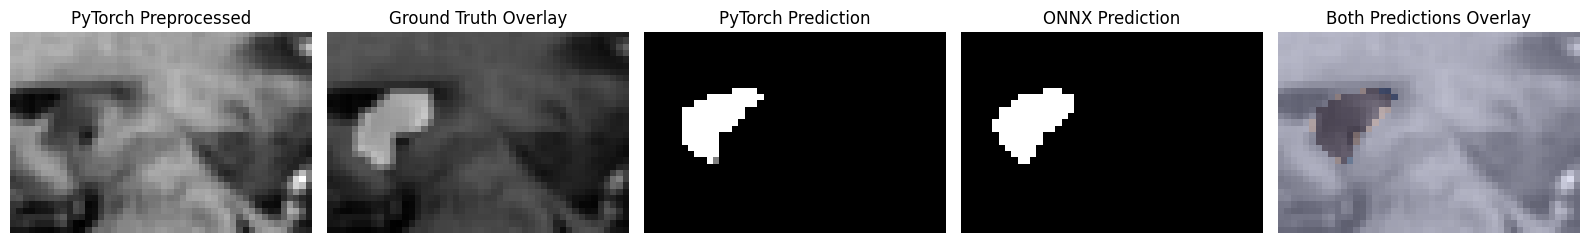

PyTorch Dice Score: 0.6409
ONNX Dice Score: 0.6803
Difference: 0.0394
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_132.nii.gz


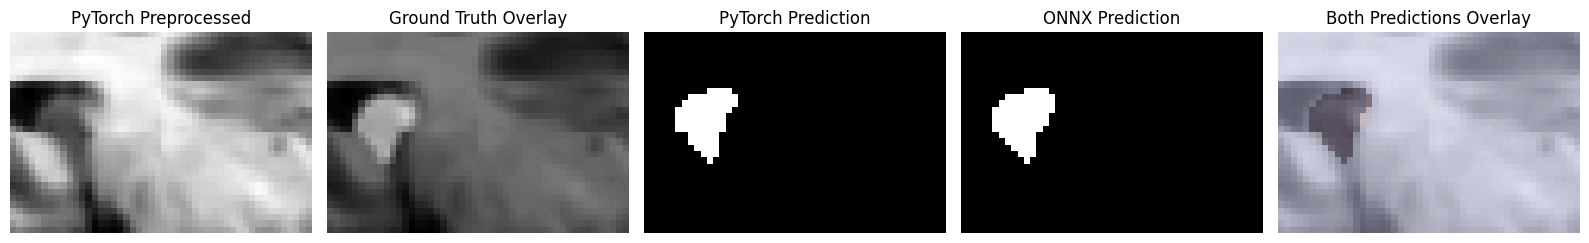

PyTorch Dice Score: 0.6239
ONNX Dice Score: 0.6677
Difference: 0.0438
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_318.nii.gz


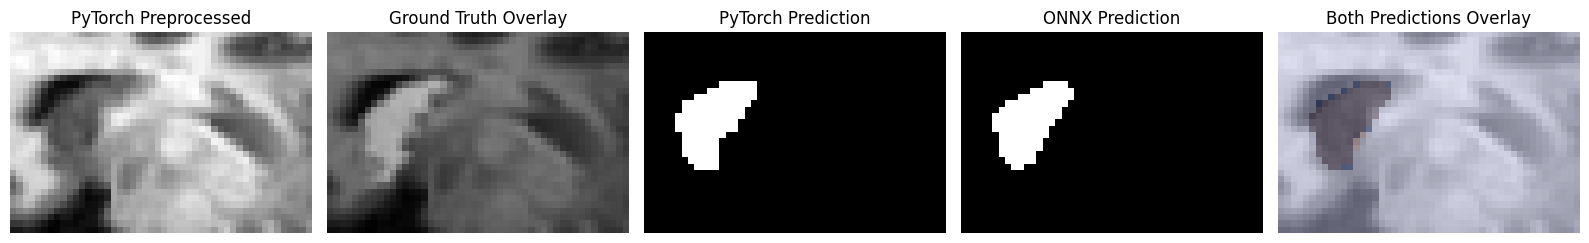

PyTorch Dice Score: 0.6551
ONNX Dice Score: 0.6895
Difference: 0.0345
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_299.nii.gz


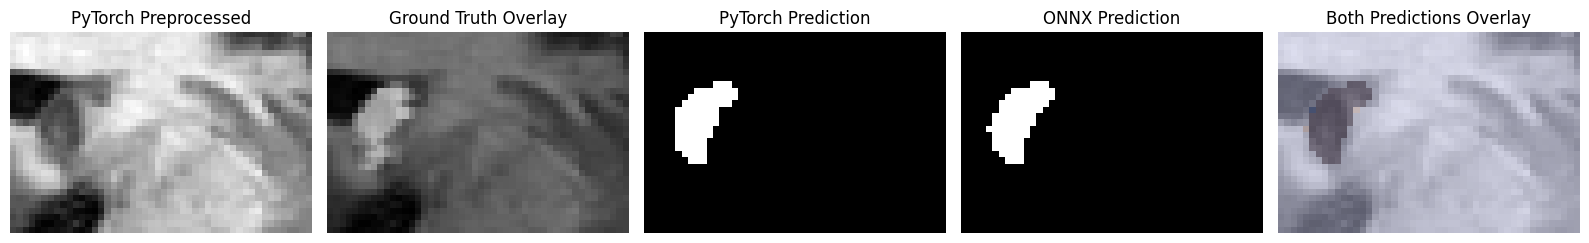

PyTorch Dice Score: 0.7182
ONNX Dice Score: 0.7248
Difference: 0.0066
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_320.nii.gz


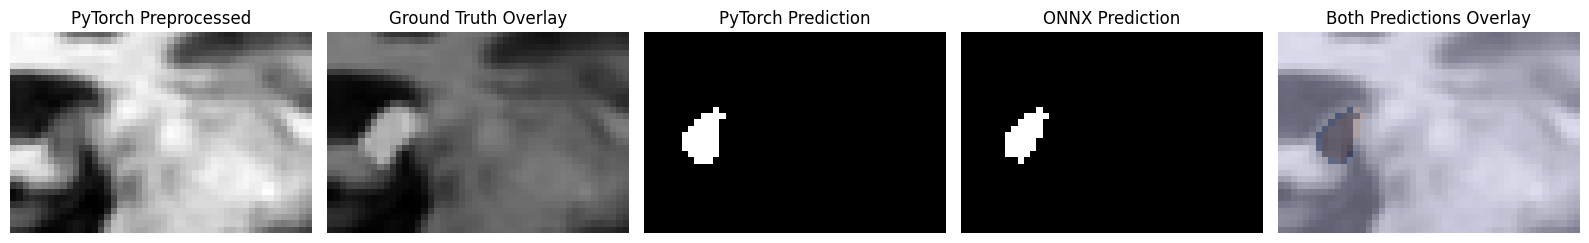

PyTorch Dice Score: 0.6314
ONNX Dice Score: 0.6286
Difference: 0.0028
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_368.nii.gz


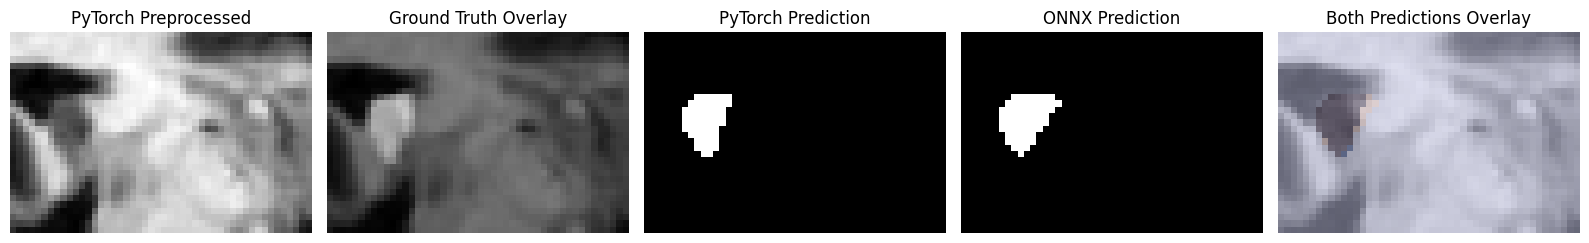

PyTorch Dice Score: 0.6922
ONNX Dice Score: 0.7704
Difference: 0.0782
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_011.nii.gz


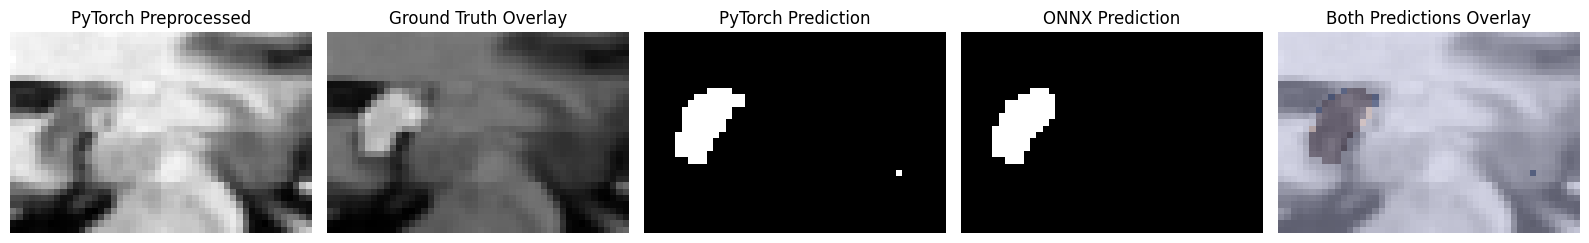

PyTorch Dice Score: 0.7502
ONNX Dice Score: 0.7586
Difference: 0.0084
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_336.nii.gz


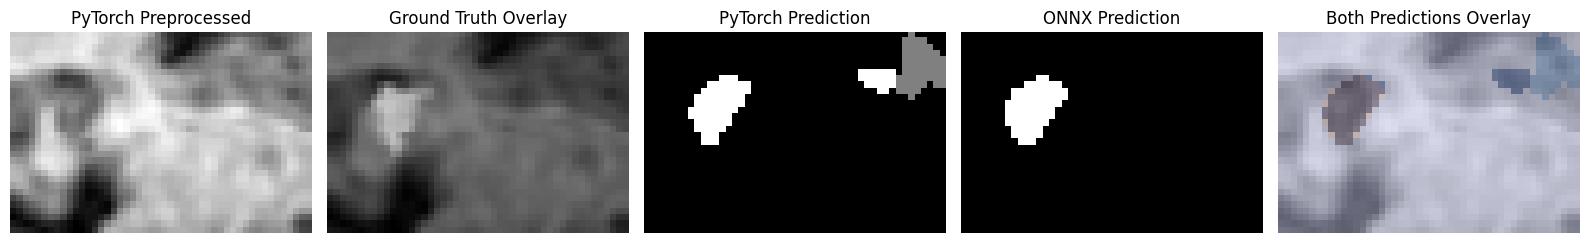

PyTorch Dice Score: 0.4499
ONNX Dice Score: 0.5538
Difference: 0.1039
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_169.nii.gz


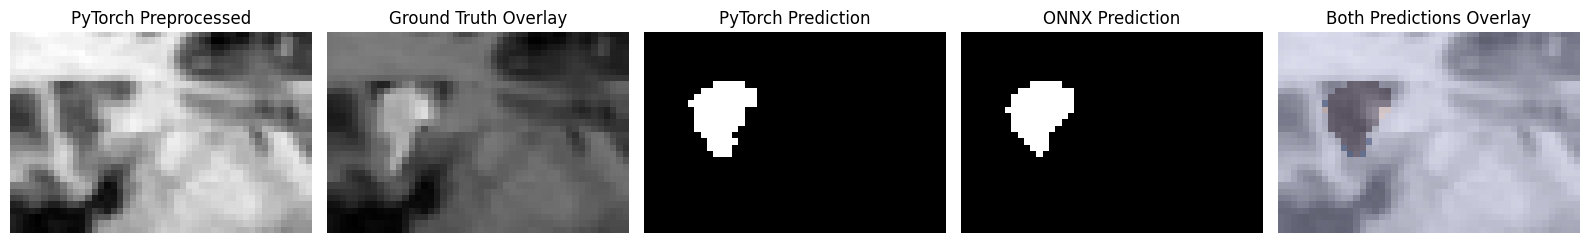

PyTorch Dice Score: 0.5847
ONNX Dice Score: 0.6566
Difference: 0.0719
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_180.nii.gz


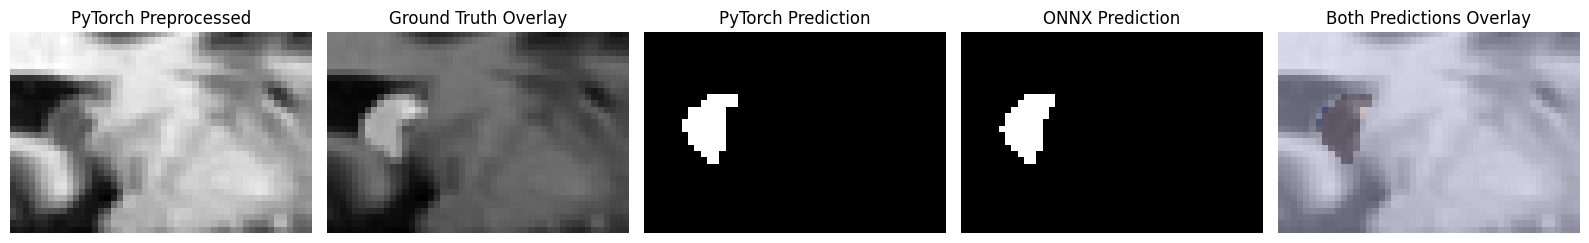

PyTorch Dice Score: 0.7227
ONNX Dice Score: 0.7285
Difference: 0.0058
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_189.nii.gz


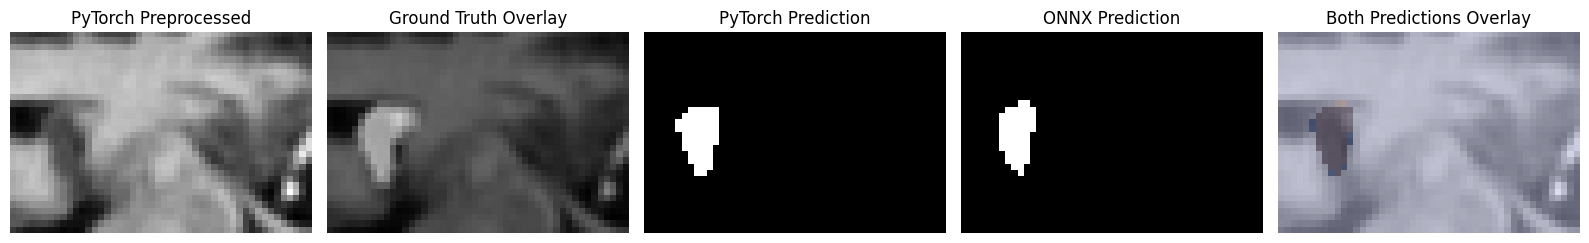

PyTorch Dice Score: 0.7286
ONNX Dice Score: 0.7416
Difference: 0.0130
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_036.nii.gz


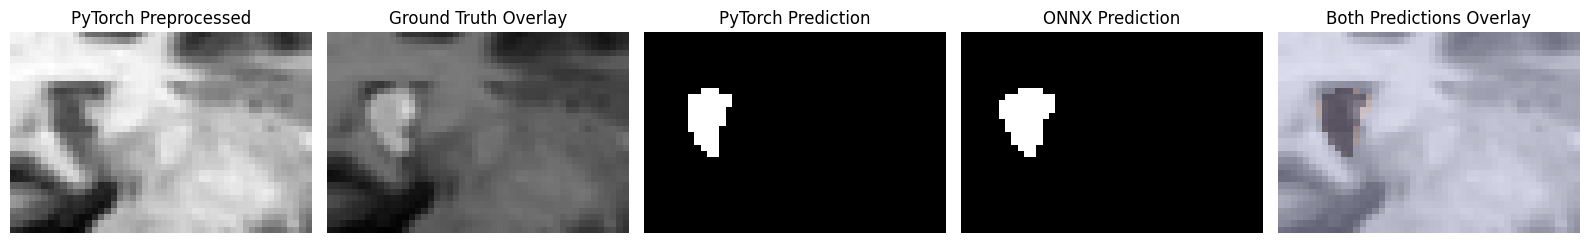

PyTorch Dice Score: 0.7064
ONNX Dice Score: 0.7182
Difference: 0.0118
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_314.nii.gz


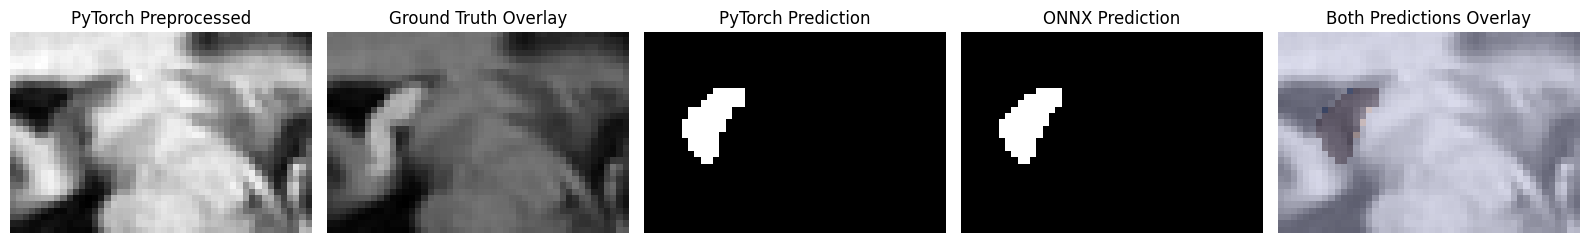

PyTorch Dice Score: 0.6810
ONNX Dice Score: 0.7060
Difference: 0.0251
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_286.nii.gz


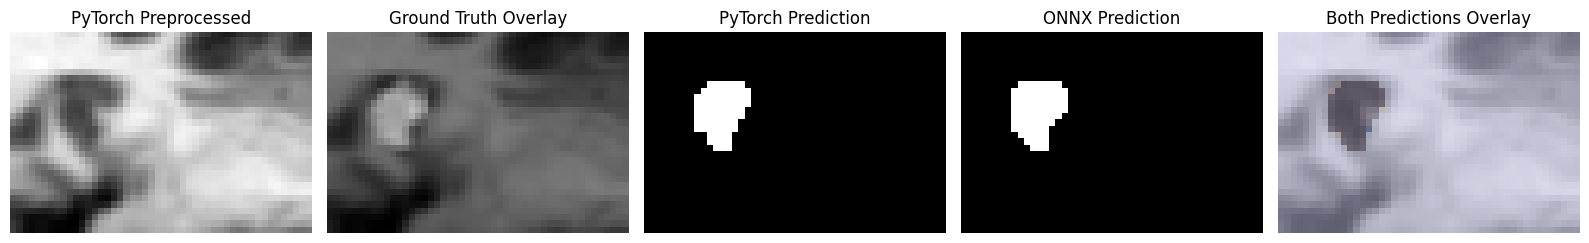

PyTorch Dice Score: 0.6388
ONNX Dice Score: 0.6567
Difference: 0.0179
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_077.nii.gz


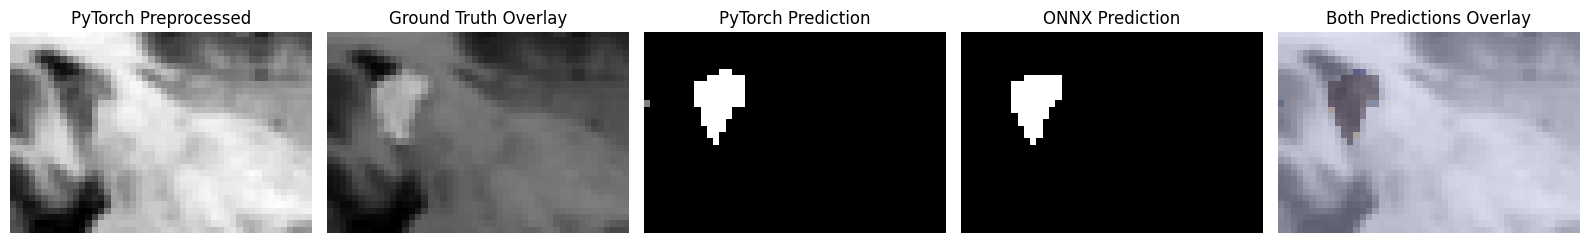

PyTorch Dice Score: 0.6465
ONNX Dice Score: 0.6833
Difference: 0.0369
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_127.nii.gz


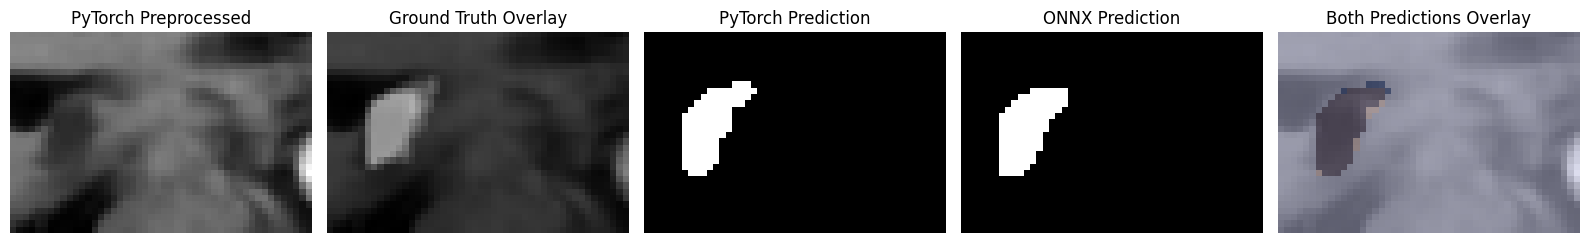

PyTorch Dice Score: 0.7351
ONNX Dice Score: 0.7723
Difference: 0.0371
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_075.nii.gz


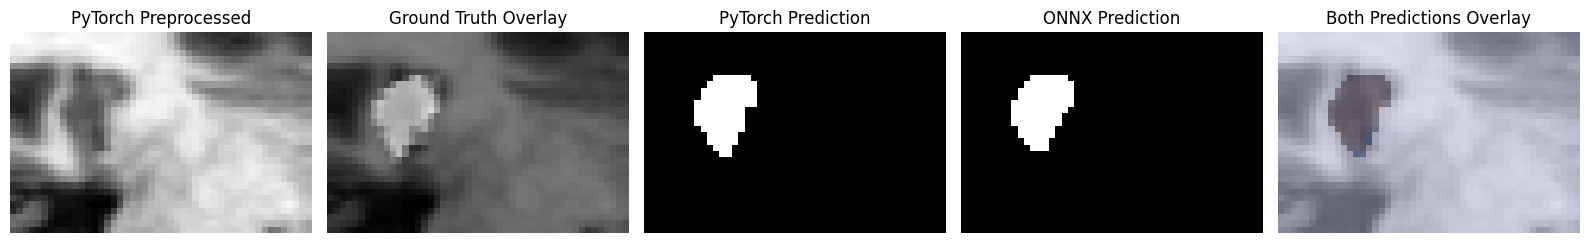

PyTorch Dice Score: 0.5732
ONNX Dice Score: 0.6347
Difference: 0.0615
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_242.nii.gz


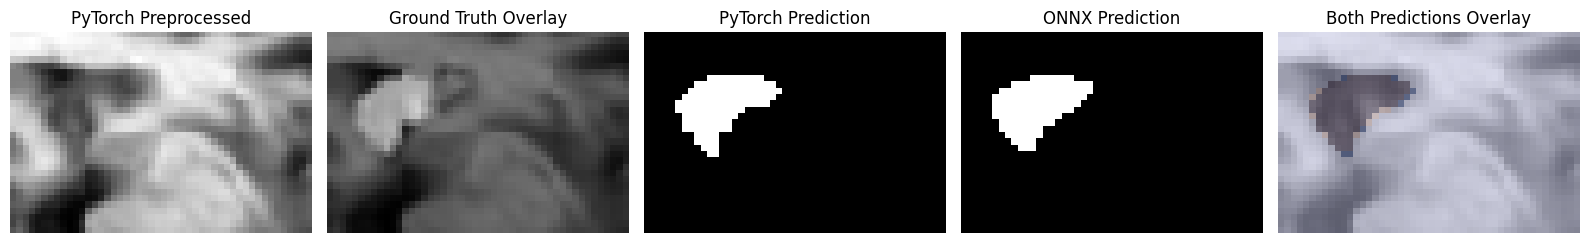

PyTorch Dice Score: 0.7349
ONNX Dice Score: 0.7956
Difference: 0.0607
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_026.nii.gz


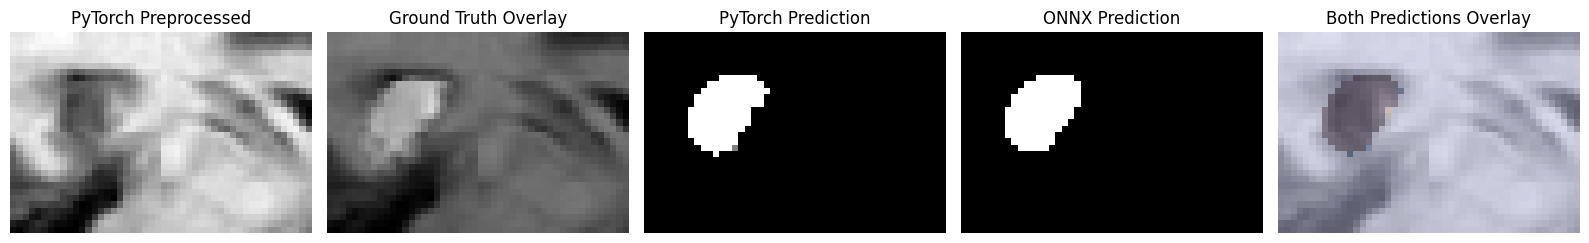

PyTorch Dice Score: 0.7129
ONNX Dice Score: 0.7618
Difference: 0.0489
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_359.nii.gz


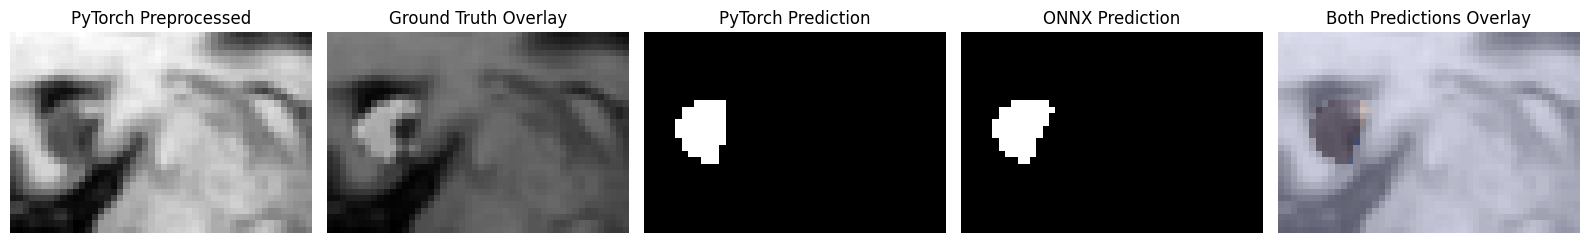

PyTorch Dice Score: 0.6599
ONNX Dice Score: 0.6732
Difference: 0.0133
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_350.nii.gz


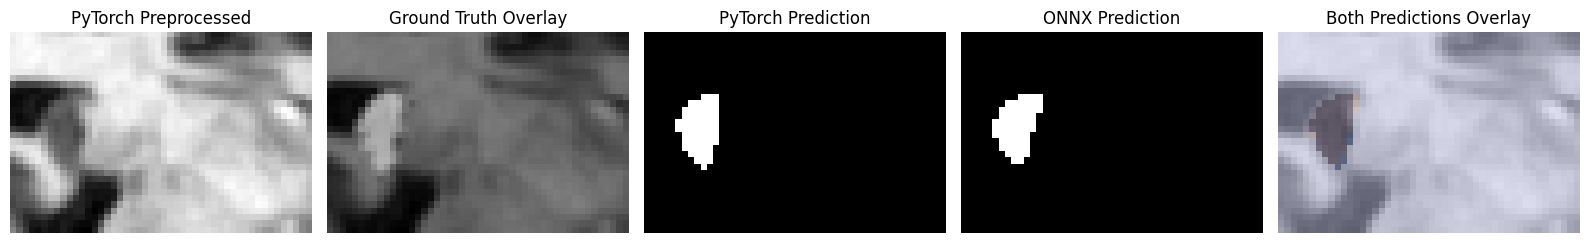

PyTorch Dice Score: 0.6494
ONNX Dice Score: 0.6608
Difference: 0.0113
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_228.nii.gz


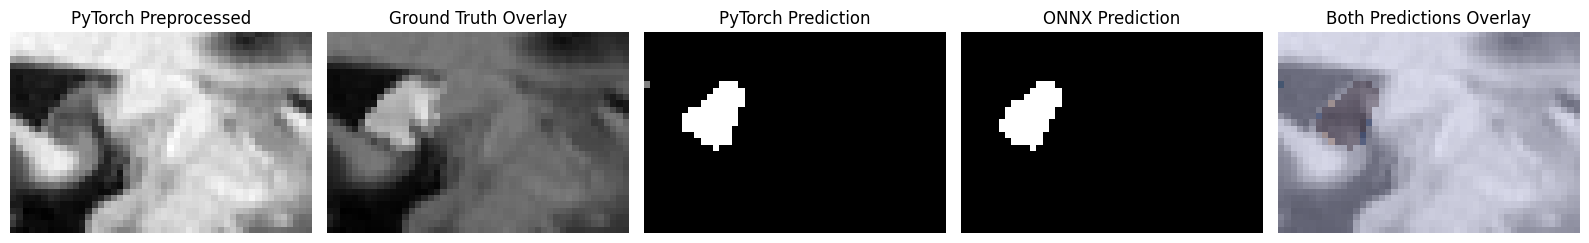

PyTorch Dice Score: 0.7357
ONNX Dice Score: 0.7442
Difference: 0.0086
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_052.nii.gz


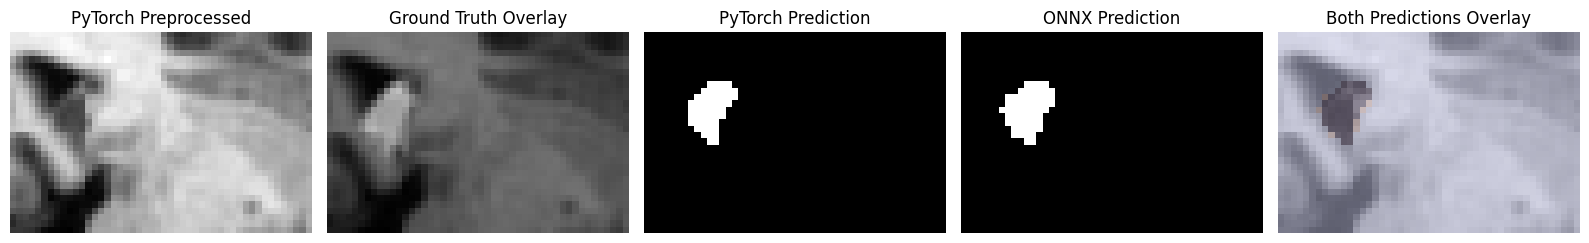

PyTorch Dice Score: 0.6292
ONNX Dice Score: 0.6548
Difference: 0.0256
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_305.nii.gz


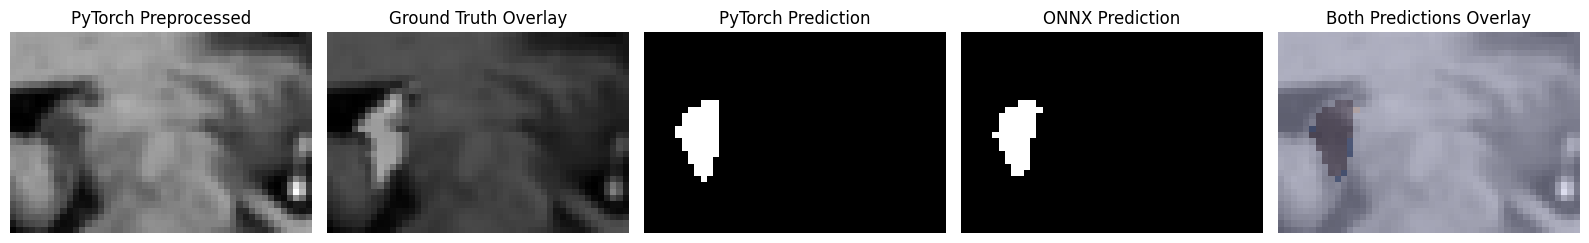

PyTorch Dice Score: 0.6969
ONNX Dice Score: 0.7213
Difference: 0.0244
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_164.nii.gz


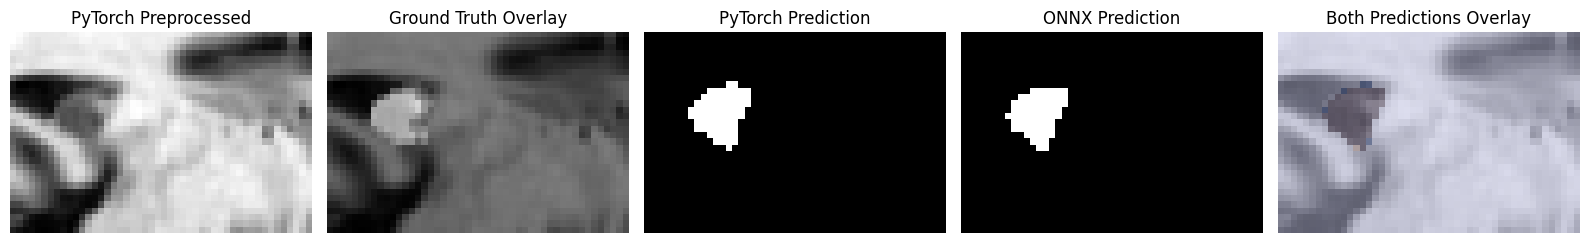

PyTorch Dice Score: 0.6271
ONNX Dice Score: 0.6332
Difference: 0.0061
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_328.nii.gz


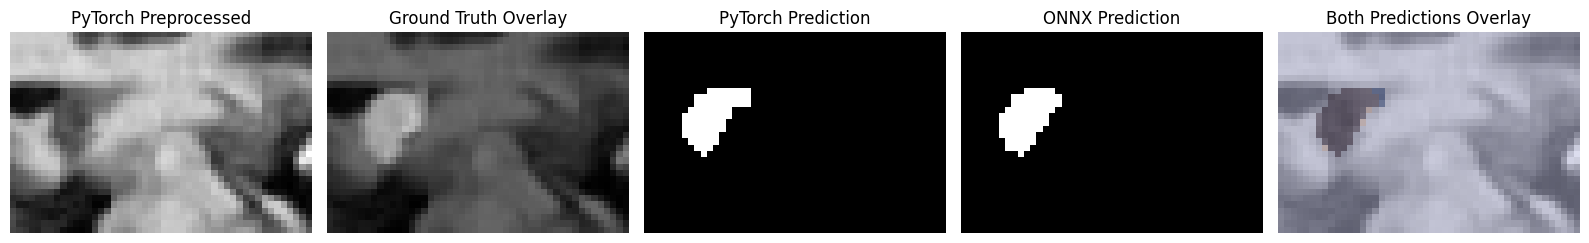

PyTorch Dice Score: 0.7161
ONNX Dice Score: 0.7597
Difference: 0.0435
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_019.nii.gz


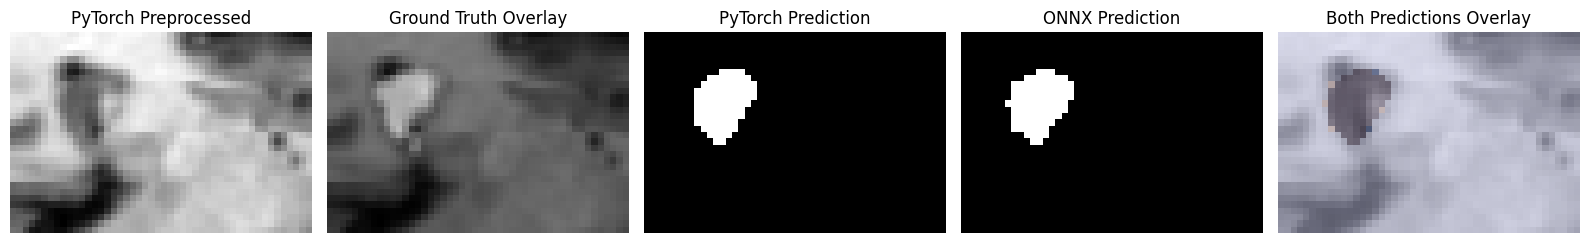

PyTorch Dice Score: 0.6792
ONNX Dice Score: 0.6958
Difference: 0.0165
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_178.nii.gz


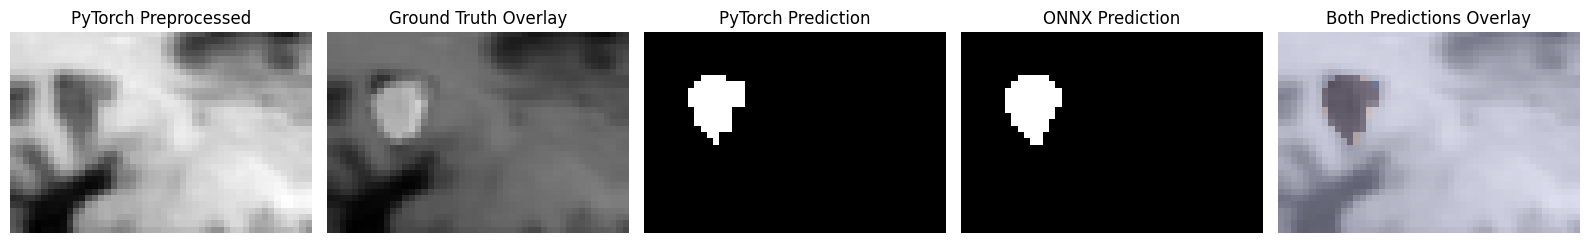

PyTorch Dice Score: 0.6595
ONNX Dice Score: 0.7123
Difference: 0.0528
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_158.nii.gz


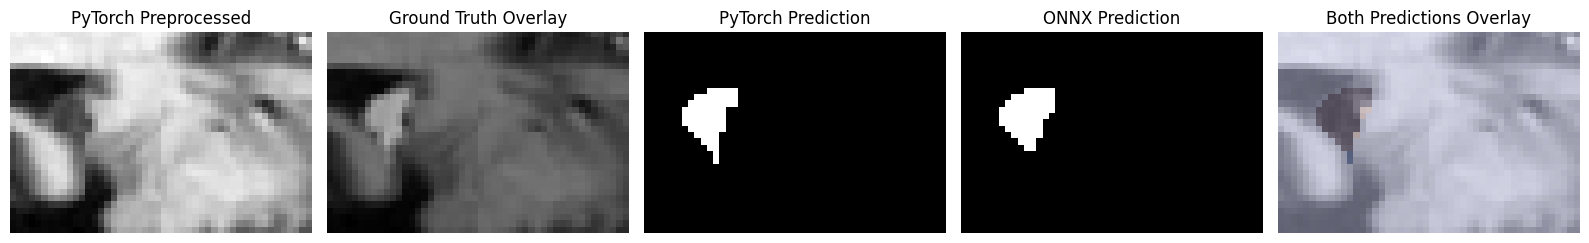

PyTorch Dice Score: 0.7024
ONNX Dice Score: 0.7188
Difference: 0.0164
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_154.nii.gz


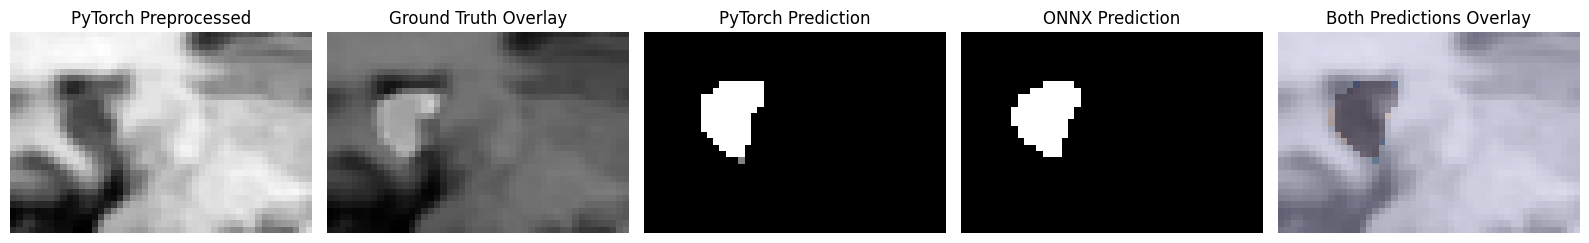

PyTorch Dice Score: 0.6840
ONNX Dice Score: 0.6883
Difference: 0.0042
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_234.nii.gz


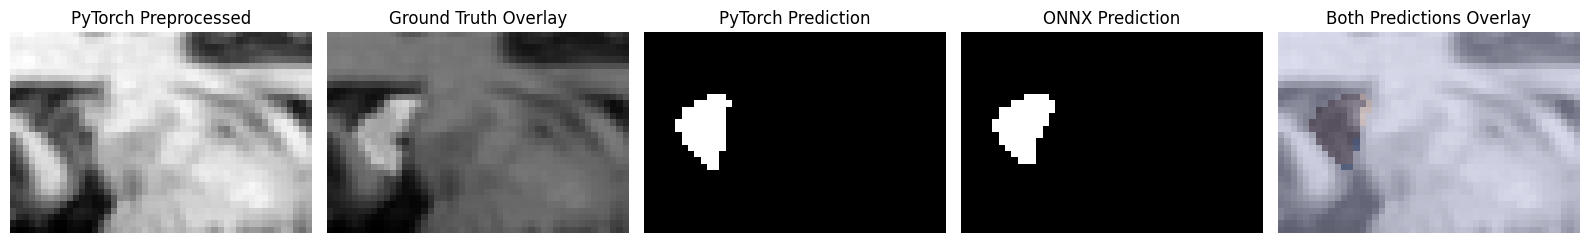

PyTorch Dice Score: 0.6403
ONNX Dice Score: 0.6956
Difference: 0.0553
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_042.nii.gz


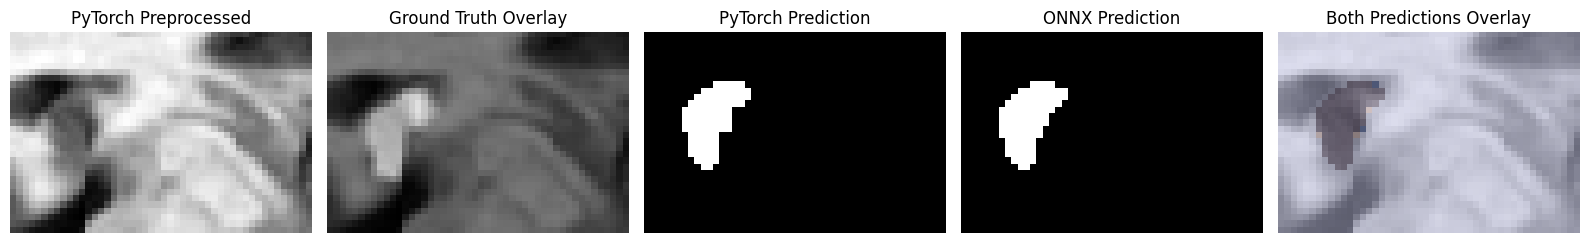

PyTorch Dice Score: 0.6966
ONNX Dice Score: 0.7035
Difference: 0.0068
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_248.nii.gz


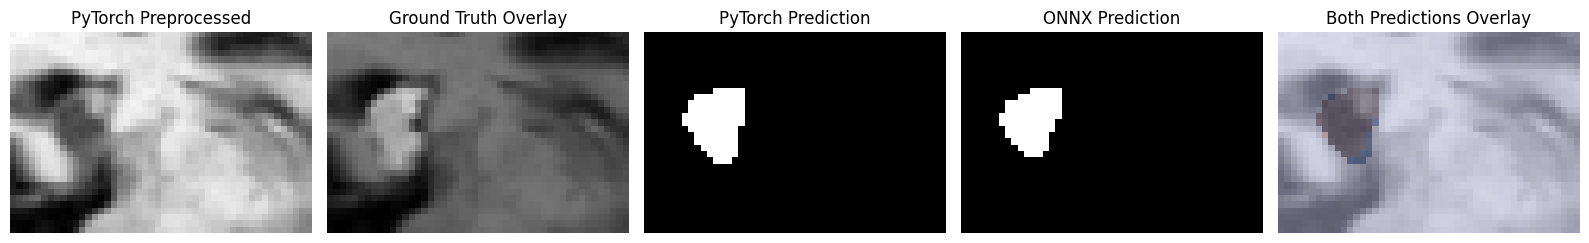

PyTorch Dice Score: 0.6169
ONNX Dice Score: 0.6657
Difference: 0.0488
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_035.nii.gz


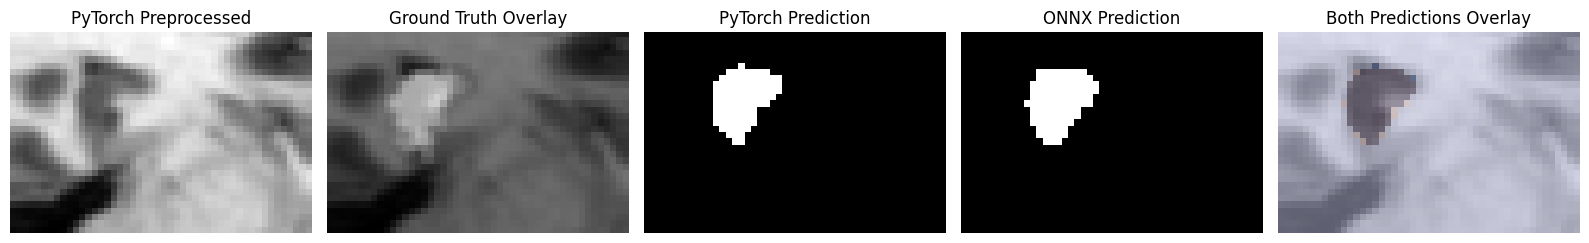

PyTorch Dice Score: 0.7038
ONNX Dice Score: 0.7367
Difference: 0.0329
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_360.nii.gz


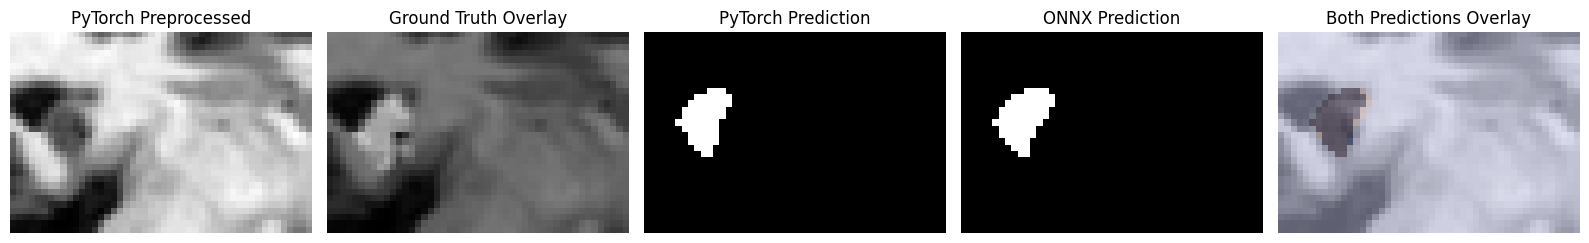

PyTorch Dice Score: 0.6219
ONNX Dice Score: 0.6189
Difference: 0.0030
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_223.nii.gz


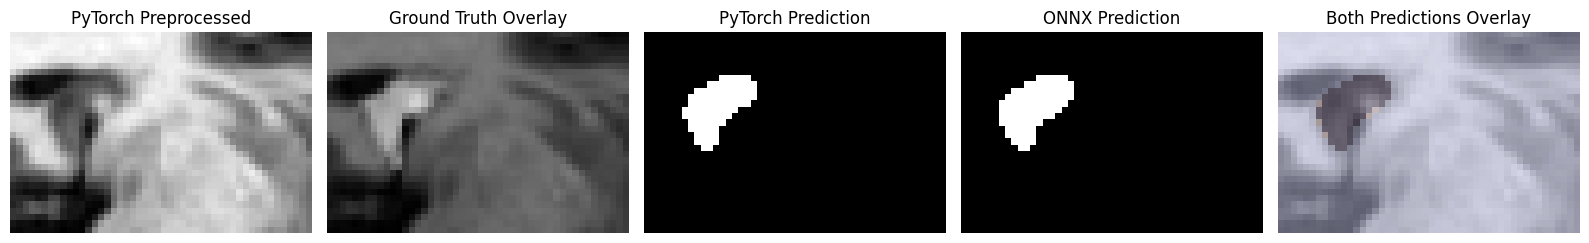

PyTorch Dice Score: 0.6204
ONNX Dice Score: 0.6448
Difference: 0.0244
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_108.nii.gz


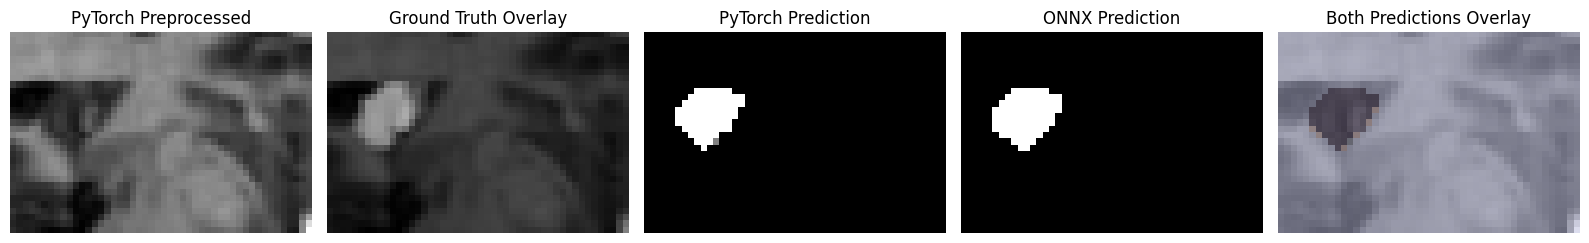

PyTorch Dice Score: 0.6909
ONNX Dice Score: 0.7350
Difference: 0.0440
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_160.nii.gz


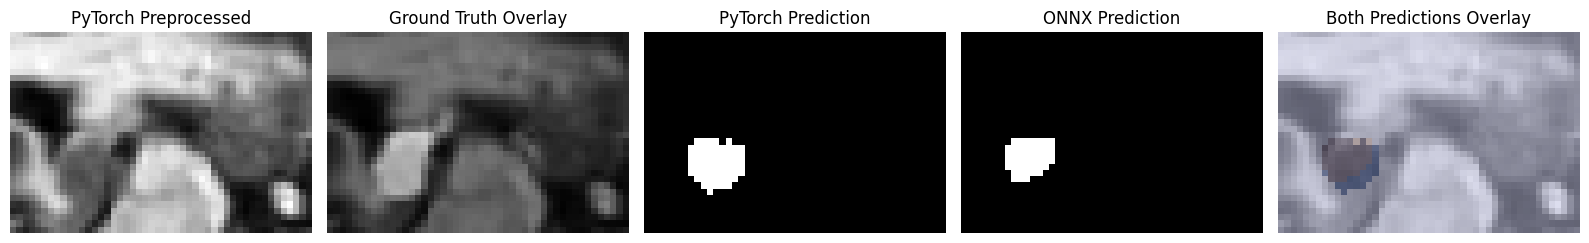

PyTorch Dice Score: 0.7015
ONNX Dice Score: 0.7655
Difference: 0.0640
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_261.nii.gz


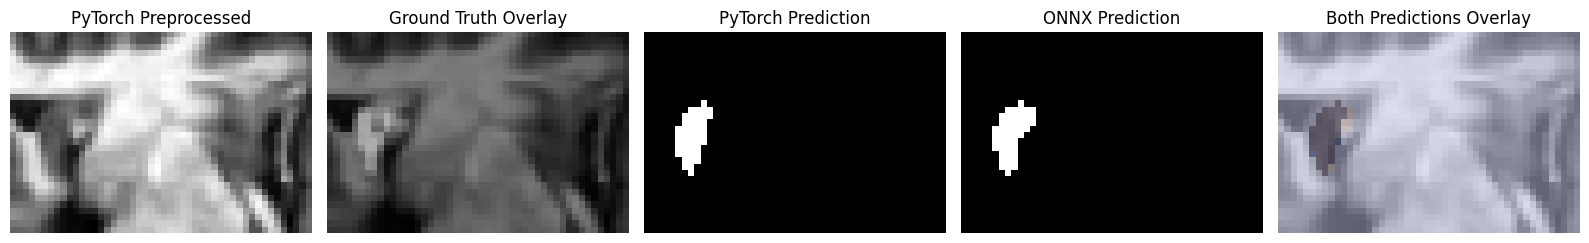

PyTorch Dice Score: 0.6830
ONNX Dice Score: 0.7119
Difference: 0.0289
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_150.nii.gz


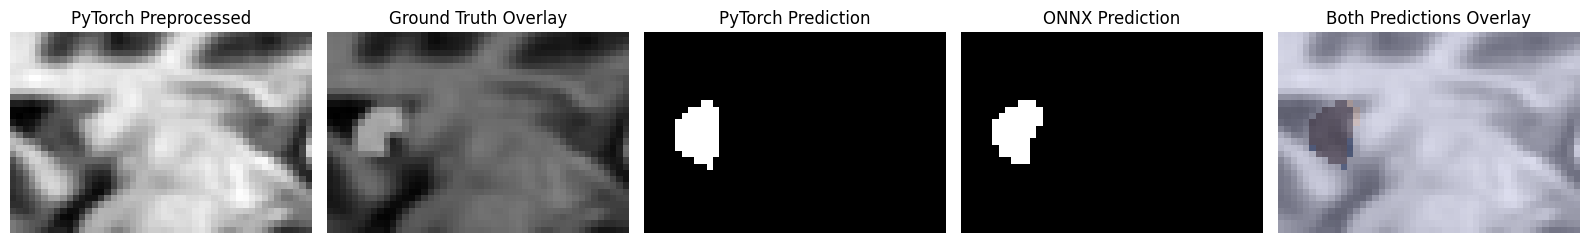

PyTorch Dice Score: 0.7433
ONNX Dice Score: 0.7841
Difference: 0.0408
Testing with raw image: Task04_Hippocampus/imagesTr/hippocampus_319.nii.gz


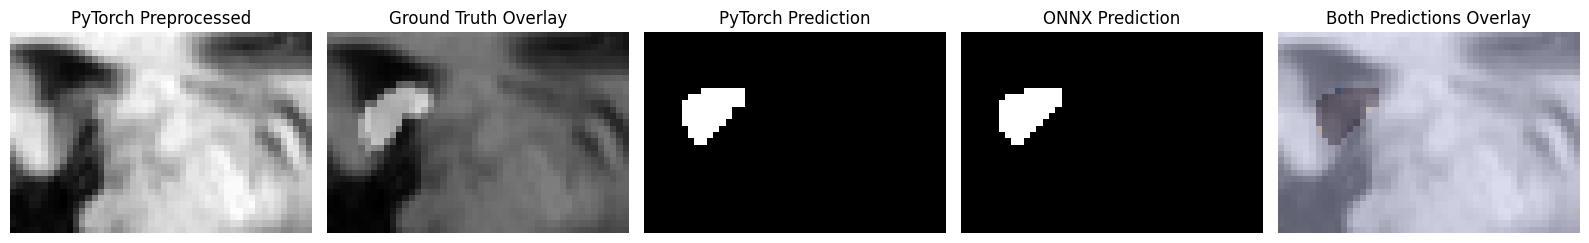

PyTorch Dice Score: 0.7185
ONNX Dice Score: 0.7115
Difference: 0.0071


In [17]:
global results 
results = []

def predict(idx):
    test_image_path = test_imgs[idx]  # Get raw image path
    print(f"Testing with raw image: {test_image_path}")

    # Test ONNX inference
    ort_session = ort.InferenceSession("hippocampus_segmentation.onnx")

    onnx_transforms = Compose([
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        ScaleIntensity(),
        Orientation(axcodes='RAS'),
        Spacing(pixdim=(1.0, 1.0, 1.0), mode='bilinear'),
        Resize(spatial_size=(32, 48, 32)),  # Match model input size
        EnsureType(data_type = "tensor"),
    ])

    # Preprocess the raw image for ONNX
    preprocessed_image = onnx_transforms(test_image_path)
    # For comparison, load the same image with test transforms
    test_sample = test_transforms({"image": test_image_path, "label": test_labels[idx]})
    pytorch_image = test_sample["image"]
    pytorch_label = test_sample["label"]

    # PyTorch inference with sliding window
    with torch.inference_mode():
        torch_pred = sliding_window_inference(pytorch_image.unsqueeze(0), (16, 16, 16), 1, model, overlap=0.25)
        torch_pred_sigmoid = torch.sigmoid(torch_pred)
        torch_pred_class = torch.argmax(torch_pred_sigmoid, dim=1, keepdim=True)

    # ONNX inference
    input_name = ort_session.get_inputs()[0].name
    output_name = ort_session.get_outputs()[0].name

    # Convert to numpy and run inference
    onnx_input = preprocessed_image.unsqueeze(0).numpy()
    onnx_output = ort_session.run([output_name], {input_name: onnx_input})[0]

    # Convert back to torch tensor and apply post-processing
    onnx_pred = torch.from_numpy(onnx_output)
    onnx_pred_sigmoid = torch.sigmoid(onnx_pred)
    onnx_pred_class = torch.argmax(onnx_pred_sigmoid, dim=1, keepdim=True)

    # Compare results
    depth = 20
    fig, axes = plt.subplots(1, 5, figsize=(16, 12))

    axes[0].imshow(pytorch_image[0, :, :, depth], cmap="gray")
    axes[0].set_title("PyTorch Preprocessed")
    axes[0].axis("off")

    axes[1].imshow(pytorch_image[0, :, :, depth], cmap="gray")
    axes[1].imshow(pytorch_label[0, :, :, depth], cmap="gray", alpha = 0.5)
    axes[1].set_title("Ground Truth Overlay")
    axes[1].axis("off")

    axes[2].imshow(torch_pred_class[0, 0, :, :, depth].cpu(), cmap="gray")
    axes[2].set_title("PyTorch Prediction")
    axes[2].axis("off")

    axes[3].imshow(onnx_pred_class[0, 0, :, :, depth].cpu(), cmap="gray")
    axes[3].set_title("ONNX Prediction")
    axes[3].axis("off")

    axes[4].imshow(onnx_pred_class[0, 0, :, :, depth].cpu(), cmap="jet", alpha=0.5)
    axes[4].imshow(torch_pred_class[0, 0, :, :, depth].cpu(), cmap = "Blues", alpha = 0.5)
    axes[4].imshow(pytorch_image[0, :, :, depth], cmap="gray", alpha=0.5)
    axes[4].set_title("Both Predictions Overlay")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()

    # Calculate dice scores to verify they match
    dice_metric.reset()
    dice_metric(y_pred=torch_pred_class, y=pytorch_label.unsqueeze(0))
    torch_dice = dice_metric.aggregate().item()

    dice_metric.reset()
    dice_metric(y_pred=onnx_pred_class, y=pytorch_label.unsqueeze(0))
    onnx_dice = dice_metric.aggregate().item()

    print(f"PyTorch Dice Score: {torch_dice:.4f}")
    print(f"ONNX Dice Score: {onnx_dice:.4f}")
    print(f"Difference: {abs(torch_dice - onnx_dice):.4f}")
    results.append((torch_dice, onnx_dice))

for i in range(len(test_ds)):
    predict(i)

### Visualize Metrics

In [29]:
torch_dice = np.array([res[0] for res in results])
onnx_dice = np.array([res[1] for res in results])

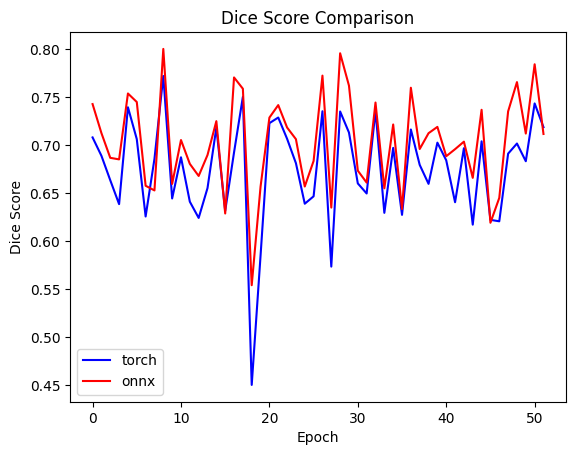

In [36]:
sns.lineplot(torch_dice, label = "torch", color='blue')
sns.lineplot(onnx_dice, label = "onnx", color='red')
plt.title("Dice Score Comparison")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.show()

In [48]:
# Onnx is better 
print("torch_dice.mean:", f"{torch_dice.mean():.4f}") 
print("torch_dice.std:", f"{torch_dice.std():.4f}") 
print("onnx_dice.mean:", f"{onnx_dice.mean():.4f}") 
print("onnx_dice.std:", f"{onnx_dice.std():.4f}")

torch_dice.mean: 0.6743
torch_dice.std: 0.0541
onnx_dice.mean: 0.7032
onnx_dice.std: 0.0499


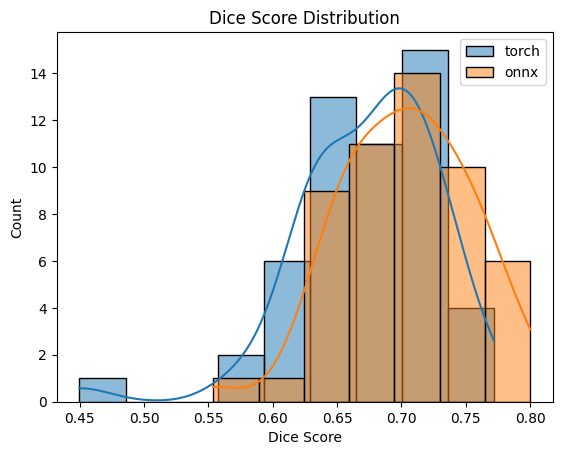

In [44]:
sns.histplot(torch_dice, kde = True, label='torch')
sns.histplot(onnx_dice, kde = True, label='onnx')
plt.xlabel('Dice Score')
plt.title("Dice Score Distribution")
plt.legend()
plt.show()